# Lab 4: YOLOv1 Object Detection from Scratch

**Goal**: Implement YOLOv1 architecture and train on Open Images Dataset

**Tasks**:

1. Implement YOLOv1 architecture (24 conv + 2 FC layers)
2. Create custom loss function (localization + confidence + classification)
3. Train on Open Images Dataset using **FiftyOne**
4. Implement NMS for post-processing
5. Evaluate with mAP metric


In [2]:
!pip install fiftyone


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 124.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.6/112.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.4/112.4 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 140.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.0/309.0 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 15.3 MB/s eta

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted at /content/drive')
    DRIVE_MOUNTED = True
except Exception as e:
    print('Google Drive not available or not running in Colab:', e)
    DRIVE_MOUNTED = False

import os
if DRIVE_MOUNTED:
    DATASET_DIR = '/content/drive/MyDrive/yolo_lab4/datasets'
    WEIGHTS_DIR = '/content/drive/MyDrive/yolo_lab4/weights'
    os.makedirs(DATASET_DIR, exist_ok=True)
    os.makedirs(WEIGHTS_DIR, exist_ok=True)
    print(f'Created {DATASET_DIR} and {WEIGHTS_DIR} to store weights/datasets')
else:
    DATASET_DIR = None
    WEIGHTS_DIR = None
    print('Drive not mounted, using local storage')

def save_model_weights(model, filename='best_yolo.pth'):
    path = os.path.join(WEIGHTS_DIR, filename) if WEIGHTS_DIR else filename
    torch.save(model.state_dict(), path)
    print(f'Model saved to: {path}')

def load_model_weights(model, filename='best_yolo.pth'):
    path = os.path.join(WEIGHTS_DIR, filename) if WEIGHTS_DIR else filename
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=torch.device('cpu' if not torch.cuda.is_available() else 'cuda')))
        print(f'Model loaded from: {path}')
    else:
        print(f'No weights found at: {path}, starting from scratch')


Mounted at /content/drive
Google Drive mounted at /content/drive
Created /content/drive/MyDrive/yolo_lab4/datasets and /content/drive/MyDrive/yolo_lab4/weights to store weights/datasets


## Setup


In [3]:
import torch
import os
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.auto import tqdm
import random

import fiftyone as fo
import fiftyone.zoo as foz

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print(f"FiftyOne version: {fo.__version__}")

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


Using device: cuda
FiftyOne version: 1.10.0


## Part 1: Configuration


In [4]:
class Config:
    # Model parameters
    S = 7
    B = 2
    C = 3

    # Image parameters
    IMG_SIZE = 448
    MAX_SAMPLES_PER_CLASS_TRAIN = 5000
    MAX_SAMPLES_PER_CLASS_VAL = 1000

    # Training parameters
    BATCH_SIZE = 32
    NUM_EPOCHS = 10
    LEARNING_RATE = 1e-3
    MOMENTUM = 0.9
    WEIGHT_DECAY = 5e-4

    LR_SCHEDULE = [
        (10, 1e-3, 1e-3),
    ]

    # Loss parameters
    LAMBDA_COORD = 5.0
    LAMBDA_NOOBJ = 0.5

    # Post-processing
    CONF_THRESHOLD = 0.2
    NMS_THRESHOLD = 0.4

    # Classes
    CLASSES = [
        "Dog",
        "Cat",
        "Bird",
    ]


cfg = Config()
print(f"Output tensor shape: {cfg.S}×{cfg.S}×{cfg.B * 5 + cfg.C}")


Output tensor shape: 7×7×13


## Part 2: YOLOv1 Architecture


In [5]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels, out_channels, kernel_size, stride, padding, bias=False
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.leaky = nn.LeakyReLU(0.1)

    def forward(self, x):
        return self.leaky(self.bn(self.conv(x)))


class YOLOv1(nn.Module):
    def __init__(self, S=7, B=2, C=10, use_pretrained=False):
        super().__init__()
        self.S = S
        self.B = B
        self.C = C

        if use_pretrained:
            import torchvision.models as models
            resnet = models.resnet34(pretrained=True)
            self.backbone = nn.Sequential(*list(resnet.children())[:-2])  # remove avgpool and fc
            self.adaptive_pool = nn.AdaptiveAvgPool2d((S, S))
            self.fc = nn.Sequential(
                nn.Flatten(),
                nn.Linear(512 * S * S, 4096),
                nn.Dropout(0.5),
                nn.LeakyReLU(0.1),
                nn.Linear(4096, S * S * (B * 5 + C)),
            )
        else:
            architecture = [
                (64, 7, 2, 3),
                "M",
                (192, 3, 1, 1),
                "M",
                (128, 1, 1, 0),
                (256, 3, 1, 1),
                (256, 1, 1, 0),
                (512, 3, 1, 1),
                "M",
                (256, 1, 1, 0),
                (512, 3, 1, 1),
                (256, 1, 1, 0),
                (512, 3, 1, 1),
                (256, 1, 1, 0),
                (512, 3, 1, 1),
                (256, 1, 1, 0),
                (512, 3, 1, 1),
                (512, 1, 1, 0),
                (1024, 3, 1, 1),
                "M",
                (512, 1, 1, 0),
                (1024, 3, 1, 1),
                (512, 1, 1, 0),
                (1024, 3, 1, 1),
                (1024, 3, 1, 1),
                (1024, 3, 2, 1),
                (1024, 3, 1, 1),
                (1024, 3, 1, 1),
            ]
            self.backbone = self._create_conv_layers(architecture)
            self.fc = self._create_fc_layers(S, B, C)

    def _create_conv_layers(self, architecture):
        layers = []
        in_channels = 3

        for x in architecture:
            if isinstance(x, tuple):
                out_channels, kernel_size, stride, padding = x
                layers.append(
                    CNNBlock(in_channels, out_channels, kernel_size, stride, padding)
                )
                in_channels = out_channels
            elif x == "M":
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

        return nn.Sequential(*layers)

    def _create_fc_layers(self, S, B, C):
        return nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024 * S * S, 4096),
            nn.Dropout(0.5),
            nn.LeakyReLU(0.1),
            nn.Linear(4096, S * S * (B * 5 + C)),
        )

    def forward(self, x):
        x = self.backbone(x)
        if hasattr(self, "adaptive_pool"):
            x = self.adaptive_pool(x)
        x = self.fc(x)
        return x.reshape(-1, self.S, self.S, self.B * 5 + self.C)


model = YOLOv1(S=cfg.S, B=cfg.B, C=cfg.C, use_pretrained=True).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

test_input = torch.randn(2, 3, cfg.IMG_SIZE, cfg.IMG_SIZE).to(device)
test_output = model(test_input)
print(f"Output shape: {test_output.shape}")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:01<00:00, 82.6MB/s]


Model parameters: 126,659,005
Output shape: torch.Size([2, 7, 7, 13])


## Part 3: YOLO Loss Function


In [6]:
def intersection_over_union(boxes_pred, boxes_target):
    """Calculate IoU between predicted and target boxes."""
    box1_x1 = boxes_pred[..., 0:1] - boxes_pred[..., 2:3] / 2
    box1_y1 = boxes_pred[..., 1:2] - boxes_pred[..., 3:4] / 2
    box1_x2 = boxes_pred[..., 0:1] + boxes_pred[..., 2:3] / 2
    box1_y2 = boxes_pred[..., 1:2] + boxes_pred[..., 3:4] / 2

    box2_x1 = boxes_target[..., 0:1] - boxes_target[..., 2:3] / 2
    box2_y1 = boxes_target[..., 1:2] - boxes_target[..., 3:4] / 2
    box2_x2 = boxes_target[..., 0:1] + boxes_target[..., 2:3] / 2
    box2_y2 = boxes_target[..., 1:2] + boxes_target[..., 3:4] / 2

    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)
    box1_area = abs((box1_x2 - box1_x1) * (box1_y2 - box1_y1))
    box2_area = abs((box2_x2 - box2_x1) * (box2_y2 - box2_y1))
    union = box1_area + box2_area - intersection

    return intersection / (union + 1e-6)


class YOLOLoss(nn.Module):
    def __init__(self, S=7, B=2, C=10, lambda_coord=5.0, lambda_noobj=0.5):
        super().__init__()
        self.S = S
        self.B = B
        self.C = C
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj
        self.mse = nn.MSELoss(reduction="sum")

    def forward(self, predictions, targets):
        predictions = predictions.reshape(-1, self.S, self.S, self.B * 5 + self.C)

        iou_b1 = intersection_over_union(predictions[..., :4], targets[..., :4])
        iou_b2 = intersection_over_union(predictions[..., 5:9], targets[..., :4])
        ious = torch.cat([iou_b1.unsqueeze(0), iou_b2.unsqueeze(0)], dim=0)

        _, best_box = torch.max(ious, dim=0)
        exists_box = targets[..., 4].unsqueeze(3)

        # Box coordinate loss
        box_predictions = exists_box * (
            best_box * predictions[..., 5:9] + (1 - best_box) * predictions[..., :4]
        )
        box_targets = exists_box * targets[..., :4]
        box_predictions[..., 2:4] = torch.sign(box_predictions[..., 2:4]) * torch.sqrt(
            torch.abs(box_predictions[..., 2:4] + 1e-6)
        )
        box_targets[..., 2:4] = torch.sqrt(box_targets[..., 2:4])
        box_loss = self.mse(
            torch.flatten(box_predictions, end_dim=-2),
            torch.flatten(box_targets, end_dim=-2),
        )

        # Object confidence loss
        pred_box = (
            best_box * predictions[..., 9:10] + (1 - best_box) * predictions[..., 4:5]
        )
        object_loss = self.mse(
            torch.flatten(exists_box * pred_box),
            torch.flatten(exists_box * targets[..., 4:5]),
        )

        # No object loss
        no_object_loss = self.mse(
            torch.flatten((1 - exists_box) * predictions[..., 4:5], start_dim=1),
            torch.flatten((1 - exists_box) * targets[..., 4:5], start_dim=1),
        )
        no_object_loss += self.mse(
            torch.flatten((1 - exists_box) * predictions[..., 9:10], start_dim=1),
            torch.flatten((1 - exists_box) * targets[..., 9:10], start_dim=1),
        )

        # Class loss
        class_loss = self.mse(
            torch.flatten(exists_box * predictions[..., 10:], end_dim=-2),
            torch.flatten(exists_box * targets[..., 10:], end_dim=-2),
        )

        loss = (
            self.lambda_coord * box_loss
            + object_loss
            + self.lambda_noobj * no_object_loss
            + class_loss
        )

        return loss


criterion = YOLOLoss(
    S=cfg.S,
    B=cfg.B,
    C=cfg.C,
    lambda_coord=cfg.LAMBDA_COORD,
    lambda_noobj=cfg.LAMBDA_NOOBJ,
)
print("YOLO Loss initialized")


YOLO Loss initialized


## Part 4: Dataset Preparation with FiftyOne


In [7]:
def setup_open_images_dataset(classes=None, max_samples=2000, split="train"):
    """Download Open Images dataset using FiftyOne."""
    dataset_name = f"open-images-v7-{split}"

    if 'DRIVE_MOUNTED' in globals() and DRIVE_MOUNTED:
        dataset_dir = '/content/drive/MyDrive/yolo_lab4/datasets'
        os.makedirs(dataset_dir, exist_ok=True)
        export_path = os.path.join(dataset_dir, dataset_name)

        if os.path.exists(export_path):
            print(f"Loading dataset from Drive: {export_path}")
            dataset = fo.Dataset.from_dir(
                dataset_dir=export_path,
                dataset_type=fo.types.FiftyOneDataset,
                name=dataset_name
            )
            return dataset
        else:
            print(f"Dataset not found on Drive, downloading...")
    else:
        export_path = None

    if fo.dataset_exists(dataset_name):
        print(f"Loading existing dataset: {dataset_name}")
        dataset = fo.load_dataset(dataset_name)
    else:
        print(f"Downloading Open Images V7 ({split} split)...")
        print(f"Classes: {classes}")
        print(f"Max samples: {max_samples}")

        dataset = foz.load_zoo_dataset(
            "open-images-v7",
            split=split,
            label_types=["detections"],
            classes=classes,
            max_samples=max_samples,
            dataset_name=dataset_name,
            shuffle=True,
        )

        print(f"✅ Downloaded {len(dataset)} samples")

    if export_path:
        print(f"Exporting dataset to Drive: {export_path}")
        dataset.export(
            export_dir=export_path,
            dataset_type=fo.types.FiftyOneDataset,
            export_media=True
        )
        print("✅ Dataset exported to Drive")

    return dataset


print("Setting up Open Images Dataset with FiftyOne...")
print(f"Selected classes: {cfg.CLASSES}")

train_fo_dataset = setup_open_images_dataset(
    classes=cfg.CLASSES, max_samples=cfg.MAX_SAMPLES_PER_CLASS_TRAIN, split="train"
)

val_fo_dataset = setup_open_images_dataset(
    classes=cfg.CLASSES, max_samples=cfg.MAX_SAMPLES_PER_CLASS_VAL, split="validation"
)

print(f"\n📊 Dataset Summary:")
print(f"Train samples: {len(train_fo_dataset)}")
print(f"Val samples: {len(val_fo_dataset)}")


Setting up Open Images Dataset with FiftyOne...
Selected classes: ['Dog', 'Cat', 'Bird']
Loading dataset from Drive: /content/drive/MyDrive/yolo_lab4/datasets/open-images-v7-train
Importing samples...


INFO:fiftyone.utils.data.importers:Importing samples...


 100% |███████████████| 5000/5000 [299.8ms elapsed, 0s remaining, 16.7K samples/s]     


INFO:eta.core.utils: 100% |███████████████| 5000/5000 [299.8ms elapsed, 0s remaining, 16.7K samples/s]     


Loading dataset from Drive: /content/drive/MyDrive/yolo_lab4/datasets/open-images-v7-validation
Importing samples...


INFO:fiftyone.utils.data.importers:Importing samples...


 100% |███████████████| 1000/1000 [34.2ms elapsed, 0s remaining, 29.2K samples/s]  


INFO:eta.core.utils: 100% |███████████████| 1000/1000 [34.2ms elapsed, 0s remaining, 29.2K samples/s]  



📊 Dataset Summary:
Train samples: 5000
Val samples: 1000


In [8]:
class FiftyOneDataset(Dataset):
    """PyTorch Dataset wrapper for FiftyOne datasets."""

    def __init__(
        self, fo_dataset, class_names, img_size=448, S=7, B=2, C=10, augment=True
    ):
        self.fo_dataset = fo_dataset
        self.class_names = class_names
        self.class_to_idx = {name: idx for idx, name in enumerate(class_names)}
        self.img_size = img_size
        self.S = S
        self.B = B
        self.C = C
        self.samples = list(fo_dataset)

        if augment:
            self.transform = transforms.Compose(
                [
                    transforms.Resize((img_size, img_size)),
                    transforms.RandomAffine(
                        degrees=0, translate=(0.2, 0.2), scale=(0.8, 1.2)
                    ),
                    transforms.ColorJitter(
                        brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05
                    ),
                    transforms.ToTensor(),
                    transforms.Normalize(
                        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                    ),
                ]
            )
        else:
            self.transform = transforms.Compose(
                [
                    transforms.Resize((img_size, img_size)),
                    transforms.ToTensor(),
                    transforms.Normalize(
                        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                    ),
                ]
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(sample.filepath).convert("RGB")
        detections = sample.ground_truth.detections if sample.ground_truth else []

        boxes = []
        labels = []

        for detection in detections:
            label = detection.label
            if label not in self.class_to_idx:
                continue

            class_id = self.class_to_idx[label]
            x_rel, y_rel, w_rel, h_rel = detection.bounding_box

            x_center = x_rel + w_rel / 2
            y_center = y_rel + h_rel / 2

            boxes.append([x_center, y_center, w_rel, h_rel])
            labels.append(class_id)

        target = self._convert_to_yolo_target(boxes, labels)
        img_tensor = self.transform(img)

        return img_tensor, target

    def _convert_to_yolo_target(self, boxes, labels):
        """Convert bounding boxes to YOLO target format."""
        target = torch.zeros(self.S, self.S, self.B * 5 + self.C)

        for box, label in zip(boxes, labels):
            x, y, w, h = box

            cell_x = int(x * self.S)
            cell_y = int(y * self.S)

            x_cell = x * self.S - cell_x
            y_cell = y * self.S - cell_y
            w_cell = w * self.S
            h_cell = h * self.S

            if target[cell_y, cell_x, 4] == 0:
                target[cell_y, cell_x, :4] = torch.tensor(
                    [x_cell, y_cell, w_cell, h_cell]
                )
                target[cell_y, cell_x, 4] = 1
                target[cell_y, cell_x, 10 + label] = 1

        return target


train_dataset = FiftyOneDataset(
    fo_dataset=train_fo_dataset,
    class_names=cfg.CLASSES,
    img_size=cfg.IMG_SIZE,
    S=cfg.S,
    B=cfg.B,
    C=cfg.C,
    augment=False,
)

val_dataset = FiftyOneDataset(
    fo_dataset=val_fo_dataset,
    class_names=cfg.CLASSES,
    img_size=cfg.IMG_SIZE,
    S=cfg.S,
    B=cfg.B,
    C=cfg.C,
    augment=False,
)

train_loader = DataLoader(
    train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=0
)
val_loader = DataLoader(
    val_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=0
)

print(f"\n📦 PyTorch Dataset Created:")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

img, target = train_dataset[0]
print(f"\n✅ Sample check:")
print(f"Image shape: {img.shape}")
print(f"Target shape: {target.shape}")



📦 PyTorch Dataset Created:
Train samples: 5000
Val samples: 1000

✅ Sample check:
Image shape: torch.Size([3, 448, 448])
Target shape: torch.Size([7, 7, 13])


### Optional: Visualize Dataset with FiftyOne


In [9]:
# Uncomment to launch FiftyOne App
# session = fo.launch_app(train_fo_dataset)

## Part 5: Training


In [11]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for images, targets in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        predictions = model(images)
        loss = criterion(predictions, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, targets in tqdm(loader, desc="Validation", leave=False):
            images = images.to(device)
            targets = targets.to(device)

            predictions = model(images)
            loss = criterion(predictions, targets)

            total_loss += loss.item()

    return total_loss / len(loader)


class YOLOLRScheduler:
    def __init__(self, optimizer, schedule):
        self.optimizer = optimizer
        self.schedule = schedule
        self.epoch = 0

    def step(self, epoch):
        self.epoch = epoch
        lr = self._get_lr(epoch)
        for param_group in self.optimizer.param_groups:
            param_group["lr"] = lr

    def _get_lr(self, epoch):
        current_epoch = 0
        for epochs, start_lr, end_lr in self.schedule:
            if epoch < current_epoch + epochs:
                phase_progress = (epoch - current_epoch) / epochs
                lr = start_lr + (end_lr - start_lr) * phase_progress
                return lr
            current_epoch += epochs
        return self.schedule[-1][2]


model = YOLOv1(S=cfg.S, B=cfg.B, C=cfg.C).to(device)
optimizer = optim.SGD(
    model.parameters(),
    lr=cfg.LEARNING_RATE,
    momentum=cfg.MOMENTUM,
    weight_decay=cfg.WEIGHT_DECAY,
)
scheduler = YOLOLRScheduler(optimizer, cfg.LR_SCHEDULE)

try:
    load_model_weights(model)
except Exception as e:
    print('Could not load weights before training:', e)

print("✅ SGD with momentum=0.9, weight_decay=0.0005")
print("✅ Final alignment: 10@1e-3")

num_epochs = sum(e for e, _, _ in cfg.LR_SCHEDULE)
best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": [], "learning_rate": []}

print(f"Starting training for {num_epochs} epochs (paper-compliant)...")
for epoch in range(num_epochs):
    scheduler.step(epoch)
    current_lr = optimizer.param_groups[0]["lr"]

    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["learning_rate"].append(current_lr)

    print(
        f"Epoch {epoch + 1}/{num_epochs} - LR: {current_lr:.6f} - "
        f"Train: {train_loss:.4f}, Val: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        try:
            save_model_weights(model)
        except Exception:
            torch.save(model.state_dict(), "best_yolo.pth")
            print("Saved model locally as fallback")
        print(f"  ✅ Best model saved (Val: {val_loss:.4f})")

print(f"\n✅ Training complete! Best val loss: {best_val_loss:.4f}")


Model loaded from: /content/drive/MyDrive/yolo_lab4/weights/best_yolo.pth
✅ SGD with momentum=0.9, weight_decay=0.0005
✅ Final alignment: 10@1e-3
Starting training for 10 epochs (paper-compliant)...


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1/10 - LR: 0.001000 - Train: 142.8073, Val: 94.6506
Model saved to: /content/drive/MyDrive/yolo_lab4/weights/best_yolo.pth
  ✅ Best model saved (Val: 94.6506)


Training:   0%|          | 0/157 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 9/10 - LR: 0.001000 - Train: 120.7993, Val: 93.4745


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 10/10 - LR: 0.001000 - Train: 118.7842, Val: 93.6117

✅ Training complete! Best val loss: 92.8062


## Part 6: Inference & Post-Processing


In [12]:
def cells_to_boxes(predictions, S=7, B=2, C=10):
    """Convert YOLO grid predictions to bounding boxes."""
    predictions = predictions.cpu()
    batch_size = predictions.shape[0]
    predictions = predictions.reshape(batch_size, S, S, B * 5 + C)

    all_boxes = []

    for batch_idx in range(batch_size):
        boxes = []

        for i in range(S):
            for j in range(S):
                class_probs = predictions[batch_idx, i, j, 10:]
                best_class = torch.argmax(class_probs).item()
                best_prob = class_probs[best_class].item()

                for b in range(B):
                    box_offset = b * 5
                    x = (predictions[batch_idx, i, j, box_offset + 0] + j) / S
                    y = (predictions[batch_idx, i, j, box_offset + 1] + i) / S
                    w = predictions[batch_idx, i, j, box_offset + 2] / S
                    h = predictions[batch_idx, i, j, box_offset + 3] / S
                    confidence = predictions[batch_idx, i, j, box_offset + 4].item()

                    score = confidence * best_prob
                    boxes.append(
                        [best_class, score, x.item(), y.item(), w.item(), h.item()]
                    )

        all_boxes.append(boxes)

    return all_boxes


def non_max_suppression(boxes, iou_threshold=0.5, conf_threshold=0.4):
    """Apply Non-Maximum Suppression to remove overlapping boxes."""
    boxes = [box for box in boxes if box[1] > conf_threshold]
    boxes = sorted(boxes, key=lambda x: x[1], reverse=True)

    boxes_after_nms = []

    while boxes:
        chosen_box = boxes.pop(0)
        boxes_after_nms.append(chosen_box)

        boxes = [
            box
            for box in boxes
            if box[0] != chosen_box[0]
            or calculate_iou(chosen_box[2:], box[2:]) < iou_threshold
        ]

    return boxes_after_nms


def calculate_iou(box1, box2):
    """Calculate IoU between two boxes in [x, y, w, h] format."""
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    box1_x1, box1_y1 = x1 - w1 / 2, y1 - h1 / 2
    box1_x2, box1_y2 = x1 + w1 / 2, y1 + h1 / 2
    box2_x1, box2_y1 = x2 - w2 / 2, y2 - h2 / 2
    box2_x2, box2_y2 = x2 + w2 / 2, y2 + h2 / 2

    inter_x1 = max(box1_x1, box2_x1)
    inter_y1 = max(box1_y1, box2_y1)
    inter_x2 = min(box1_x2, box2_x2)
    inter_y2 = min(box1_y2, box2_y2)

    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)

    box1_area = w1 * h1
    box2_area = w2 * h2
    union_area = box1_area + box2_area - inter_area

    return inter_area / (union_area + 1e-6)


print("Post-processing functions ready")


Post-processing functions ready


## Part 7: Visualization


Model loaded from: /content/drive/MyDrive/yolo_lab4/weights/best_yolo.pth


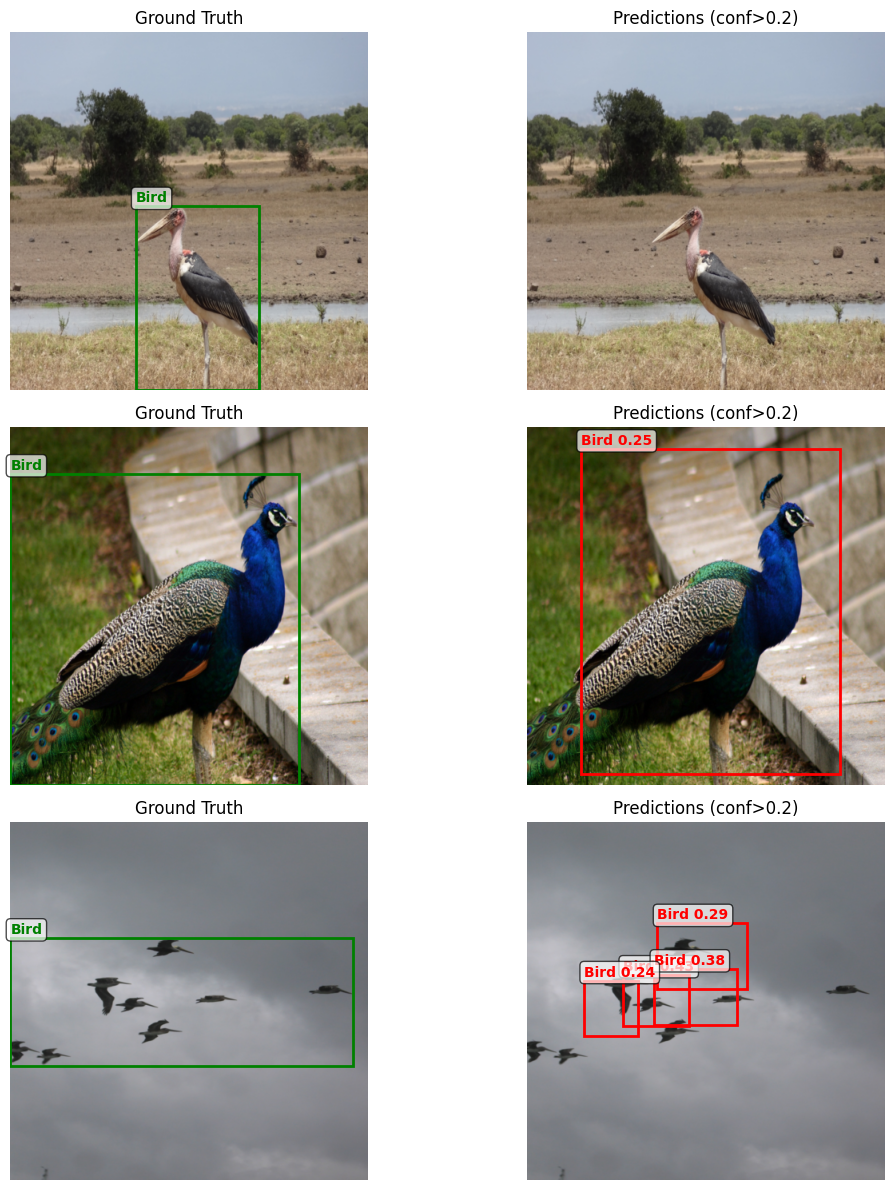

In [13]:
def visualize_predictions(
    model, dataset, num_samples=3, conf_threshold=0.3, nms_threshold=0.4
):
    """Visualize model predictions on sample images."""
    model.eval()

    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 4 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for idx in range(num_samples):
        img, target = dataset[idx]

        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_denorm = torch.clamp(img * std + mean, 0, 1)

        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(device))
            boxes = cells_to_boxes(pred, S=cfg.S, B=cfg.B, C=cfg.C)[0]
            boxes = non_max_suppression(
                boxes, iou_threshold=nms_threshold, conf_threshold=conf_threshold
            )

        # Plot ground truth
        ax = axes[idx, 0]
        ax.imshow(img_denorm.permute(1, 2, 0).cpu().numpy())
        ax.set_title("Ground Truth")
        ax.axis("off")

        for i in range(cfg.S):
            for j in range(cfg.S):
                if target[i, j, 4] > 0:
                    x = (target[i, j, 0] + j) / cfg.S
                    y = (target[i, j, 1] + i) / cfg.S
                    w = target[i, j, 2] / cfg.S
                    h = target[i, j, 3] / cfg.S

                    x1 = (x - w / 2) * cfg.IMG_SIZE
                    y1 = (y - h / 2) * cfg.IMG_SIZE
                    width = w * cfg.IMG_SIZE
                    height = h * cfg.IMG_SIZE

                    rect = patches.Rectangle(
                        (x1, y1),
                        width,
                        height,
                        linewidth=2,
                        edgecolor="g",
                        facecolor="none",
                    )
                    ax.add_patch(rect)

                    class_id = torch.argmax(target[i, j, 10:]).item()
                    ax.text(
                        x1,
                        y1 - 5,
                        cfg.CLASSES[class_id],
                        color="g",
                        fontsize=10,
                        weight="bold",
                        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
                    )

        # Plot predictions
        ax = axes[idx, 1]
        ax.imshow(img_denorm.permute(1, 2, 0).cpu().numpy())
        ax.set_title(f"Predictions (conf>{conf_threshold})")
        ax.axis("off")

        for box in boxes:
            class_id, conf, x, y, w, h = box

            x1 = (x - w / 2) * cfg.IMG_SIZE
            y1 = (y - h / 2) * cfg.IMG_SIZE
            width = w * cfg.IMG_SIZE
            height = h * cfg.IMG_SIZE

            rect = patches.Rectangle(
                (x1, y1), width, height, linewidth=2, edgecolor="r", facecolor="none"
            )
            ax.add_patch(rect)

            label = f"{cfg.CLASSES[int(class_id)]} {conf:.2f}"
            ax.text(
                x1,
                y1 - 5,
                label,
                color="r",
                fontsize=10,
                weight="bold",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
            )

    plt.tight_layout()
    plt.show()


try:
    load_model_weights(model)
except Exception as e:
    print('Could not load weights:', e)

visualize_predictions(
    model,
    val_dataset,
    num_samples=3,
    conf_threshold=cfg.CONF_THRESHOLD,
    nms_threshold=cfg.NMS_THRESHOLD,
)


## Part 8: Evaluation Metrics


In [14]:
def calculate_map(
    model, dataloader, iou_threshold=0.5, conf_threshold=0.3, nms_threshold=0.4
):
    """Calculate mean Average Precision (mAP)."""
    model.eval()
    all_pred_boxes = []
    all_true_boxes = []

    for batch_idx, (images, targets) in enumerate(
        tqdm(dataloader, desc="Calculating mAP")
    ):
        images = images.to(device)

        with torch.no_grad():
            predictions = model(images)

        batch_size = images.shape[0]
        boxes = cells_to_boxes(predictions, S=cfg.S, B=cfg.B, C=cfg.C)

        for idx in range(batch_size):
            nms_boxes = non_max_suppression(
                boxes[idx], iou_threshold=nms_threshold, conf_threshold=conf_threshold
            )

            for box in nms_boxes:
                all_pred_boxes.append([batch_idx * batch_size + idx] + box)

            for i in range(cfg.S):
                for j in range(cfg.S):
                    if targets[idx, i, j, 4] > 0:
                        class_id = torch.argmax(targets[idx, i, j, 10:]).item()
                        x = (targets[idx, i, j, 0] + j) / cfg.S
                        y = (targets[idx, i, j, 1] + i) / cfg.S
                        w = targets[idx, i, j, 2] / cfg.S
                        h = targets[idx, i, j, 3] / cfg.S

                        all_true_boxes.append(
                            [
                                batch_idx * batch_size + idx,
                                class_id,
                                1.0,
                                x.item(),
                                y.item(),
                                w.item(),
                                h.item(),
                            ]
                        )

    average_precisions = []

    for c in range(cfg.C):
        detections = [box for box in all_pred_boxes if box[1] == c]
        ground_truths = [box for box in all_true_boxes if box[1] == c]

        if len(ground_truths) == 0:
            continue

        detections = sorted(detections, key=lambda x: x[2], reverse=True)

        TP = torch.zeros(len(detections))
        FP = torch.zeros(len(detections))
        total_true_boxes = len(ground_truths)

        matched_gt = set()

        for detection_idx, detection in enumerate(detections):
            img_id = detection[0]
            best_iou = 0
            best_gt_idx = -1

            for gt_idx, gt in enumerate(ground_truths):
                if gt[0] != img_id:
                    continue

                iou = calculate_iou(detection[3:], gt[3:])

                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx

            if best_iou > iou_threshold and best_gt_idx not in matched_gt:
                TP[detection_idx] = 1
                matched_gt.add(best_gt_idx)
            else:
                FP[detection_idx] = 1

        TP_cumsum = torch.cumsum(TP, dim=0)
        FP_cumsum = torch.cumsum(FP, dim=0)

        precisions = TP_cumsum / (TP_cumsum + FP_cumsum + 1e-6)
        recalls = TP_cumsum / (total_true_boxes + 1e-6)

        precisions = torch.cat([torch.tensor([1]), precisions])
        recalls = torch.cat([torch.tensor([0]), recalls])

        ap = torch.trapz(precisions, recalls)
        average_precisions.append(ap.item())

    return (
        sum(average_precisions) / len(average_precisions) if average_precisions else 0.0
    )


try:
    load_model_weights(model)
except Exception as e:
    print('Could not load weights:', e)

mAP = calculate_map(
    model,
    val_loader,
    conf_threshold=cfg.CONF_THRESHOLD,
    nms_threshold=cfg.NMS_THRESHOLD,
)
print(f"\nmAP@0.5: {mAP:.4f}")


Model loaded from: /content/drive/MyDrive/yolo_lab4/weights/best_yolo.pth


Calculating mAP:   0%|          | 0/32 [00:00<?, ?it/s]


mAP@0.5: 0.2113


## Part 9: Training Curves


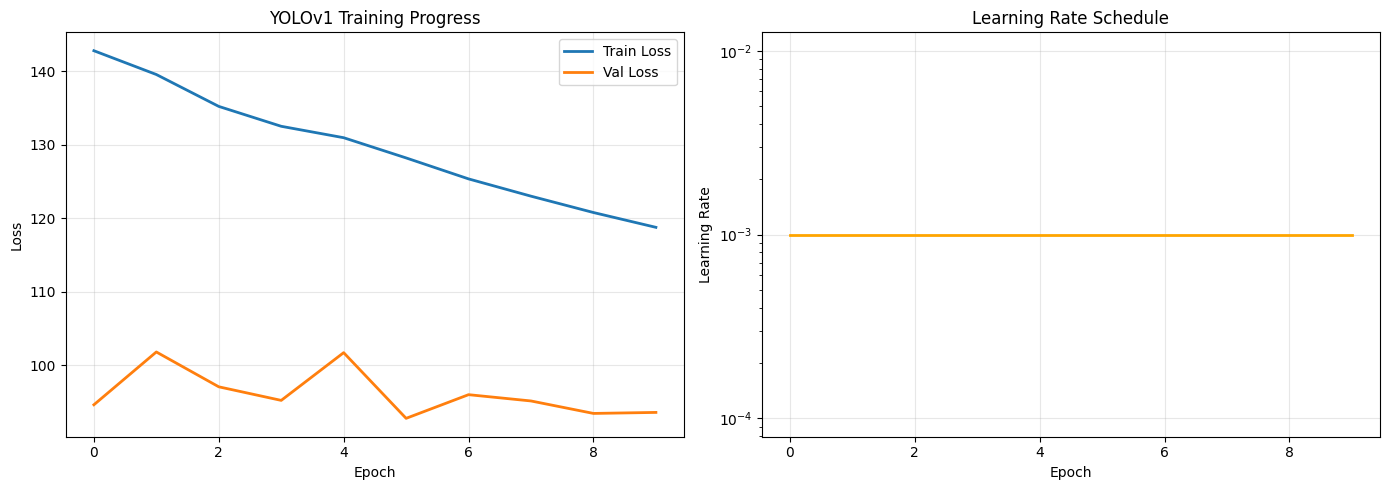

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(history["val_loss"], label="Val Loss", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("YOLOv1 Training Progress")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["learning_rate"], linewidth=2, color="orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Learning Rate")
axes[1].set_title("Learning Rate Schedule")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Results Summary


In [16]:
print("LAB 4: YOLOv1 OBJECT DETECTION - RESULTS SUMMARY")
print("\n📊 Model Configuration:")
print(f"   - Grid size: {cfg.S}×{cfg.S}")
print(f"   - Boxes per cell: {cfg.B}")
print(f"   - Number of classes: {cfg.C}")
print(f"   - Input size: {cfg.IMG_SIZE}×{cfg.IMG_SIZE}")
print(f"   - Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print("\n🎯 Training Results:")
print(f"   - Best val loss: {best_val_loss:.4f}")
print(f"   - Epochs trained: {len(history['train_loss'])}")
print("\n📈 Evaluation Metrics:")
print(f"   - mAP@0.5: {mAP:.4f}")
print(f"   - Confidence threshold: {cfg.CONF_THRESHOLD}")
print(f"   - NMS threshold: {cfg.NMS_THRESHOLD}")

LAB 4: YOLOv1 OBJECT DETECTION - RESULTS SUMMARY

📊 Model Configuration:
   - Grid size: 7×7
   - Boxes per cell: 2
   - Number of classes: 3
   - Input size: 448×448
   - Total parameters: 268,303,933

🎯 Training Results:
   - Best val loss: 92.8062
   - Epochs trained: 10

📈 Evaluation Metrics:
   - mAP@0.5: 0.2113
   - Confidence threshold: 0.2
   - NMS threshold: 0.4
